# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

I used ChatGPT to improve the prompts I wrote for the LLMs. I also used ChatGPT to help me with the syntax for the different models in Task 3 and also to decide which model to use in Task 3 c.

## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.

In [1]:
from openai import OpenAI

# --- Configuration ---
# Change the model name here to use a different model
MODEL = "gemma3:270m"

# Connect to the local Ollama server
ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"  # required by the library but ignored by Ollama
)

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

In [2]:
def ask_llm(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = ollama_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

print(ask_llm("What is the capital of Finland?"))

The capital of Finland is Helsinki.



c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [3]:
MODEL = "gemma3:4b"

print(ask_llm("How do you print Hello World in JavaScript? Answer with just the code."))

```javascript
console.log("Hello World");
```



### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

In [4]:
import pandas as pd

# Reading the headers from the csv to the variable email_headers
with open("data/emails.csv", "r", ) as f:
    email_headers = f.read().splitlines()

email_headers = email_headers[1:]
df_emails = pd.DataFrame(email_headers, columns=["subject"])

def classify_emails(email_header):
    """Classify a single email subject as Spam, Work, or Vague."""

    prompt = f"""
    You are classifying email subject lines.

    Classify the email subject into exactly one of these categories:

    Spam:
    - Promotional, scam-like, suspicious, misleading, or irrelevant mass email.
    - Examples: "You won a prize", "Limited time offer", "Claim your reward", "Urgent account warning".

    Work:
    - Clearly related to work, business, studies, meetings, invoices, projects, customers, HR, scheduling, or professional communication.
    - Examples: "Meeting notes from today", "Invoice for March", "Project update", "Question about payroll".

    Vague:
    - Too unclear to classify from the subject line alone.
    - Use this when the subject could be either spam or legitimate without more context.
    - Examples: "Hello", "Important", "Question", "Update", "Please read".

    Respond with exactly one word: Spam, Work, or Vague.

    Email subject:
    {email_header}
    """

    result = ask_llm(prompt)
    return result.strip()

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

In [5]:
MODEL = "gemma3:270m"

df_emails["classification_270m"] = df_emails["subject"].apply(classify_emails)

df_emails

,subject,classification_270m
0,URGENT: Your account will be suspended within ...,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam
2,Hot singles in your area are waiting to meet y...,
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam
4,Meeting agenda for Thursday's project review,Spam
5,"Q3 budget report attached, please review by Fr...",Vague
6,Reminder: Annual performance review scheduled ...,
7,"Updated draft of the manuscript, comments welcome",
8,Quick question about last week,Spam
9,Following up,


c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

In [6]:
MODEL = "gemma3:4b"

df_emails["classification_4b"] = df_emails["subject"].apply(classify_emails)

df_emails

,subject,classification_270m,classification_4b
0,URGENT: Your account will be suspended within ...,Spam,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam,Spam
2,Hot singles in your area are waiting to meet y...,,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam,Work
4,Meeting agenda for Thursday's project review,Spam,Work
5,"Q3 budget report attached, please review by Fr...",Vague,Work
6,Reminder: Annual performance review scheduled ...,,Work
7,"Updated draft of the manuscript, comments welcome",,Work
8,Quick question about last week,Spam,Vague
9,Following up,,Vague


Comment: *None of the models get all of the classifications 100% right, but the larger model is a lot more reliable. The smaller model shows more variation because it has weaker instruction following ability, so the randomness more often pushes it off the expected output format. The larger 4b model is more consistent because it more reliably follows the instruction to respond with exactly one word*

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [7]:
df_repeated_classifications = df_emails[["subject"]].copy()

for i in range(1, 4):
    MODEL = "gemma3:270m"
    df_repeated_classifications[f"classification_270m_{i}"] = (
        df_repeated_classifications["subject"].apply(classify_emails)
    )

    MODEL = "gemma3:4b"
    df_repeated_classifications[f"classification_4b_{i}"] = (
        df_repeated_classifications["subject"].apply(classify_emails)
    )

df_repeated_classifications = df_repeated_classifications.reindex(
    sorted(df_repeated_classifications.columns, reverse=True),
    axis=1
)

display(df_repeated_classifications)

,subject,classification_4b_3,classification_4b_2,classification_4b_1,classification_270m_3,classification_270m_2,classification_270m_1
0,URGENT: Your account will be suspended within ...,Spam,Spam,Spam,,Urgent,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam,Spam,Spam,,Spam,
2,Hot singles in your area are waiting to meet y...,Spam,Spam,Spam,Spam,Spam,Work
3,Re: Inheritance transfer of 4.5M USD pending y...,Work,Work,Work,Spam,Spam,Spam
4,Meeting agenda for Thursday's project review,Work,Work,Work,Spam,,Spam
5,"Q3 budget report attached, please review by Fr...",Work,Work,Work,Spam,,Spam
6,Reminder: Annual performance review scheduled ...,Work,Work,Work,Spam,Spam,Spam
7,"Updated draft of the manuscript, comments welcome",Work,Work,Work,,,Spam
8,Quick question about last week,Vague,Vague,Vague,Spam,Spam,Spam
9,Following up,Vague,Vague,Vague,,,


Comment: *The classifications varied between runs, especially for the smaller 270m model. This is because smaller models are trained are generally more unreliable as they are trained on less data.*

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

In [8]:
df_news = pd.read_csv("data/news.csv", delimiter="@")

def classify_headlines(headline):
    """Classify a news headline by topic and sentiment. Returns JSON text."""

    prompt = f"""
    You are classifying fictional financial news headlines.

    Classify the headline into exactly one topic:

    Earnings:
    - Company financial results, profit, revenue, sales, margins, forecasts, guidance, quarterly results, annual results, or earnings reports.

    Mergers:
    - Mergers, acquisitions, takeovers, buyouts, bids, deals, divestments, or companies buying/selling business units.

    Regulation:
    - Laws, rules, investigations, fines, compliance, regulators, government decisions, antitrust, tax rules, or legal restrictions affecting companies or markets.

    Macroeconomics:
    - Interest rates, inflation, GDP, unemployment, recession, economic growth, central banks, exchange rates, consumer confidence, or broad market/economic conditions.

    Also classify the sentiment into exactly one sentiment:

    Positive:
    - The headline suggests improvement, growth, higher profits, successful deals, positive outlook, lower risks, or favorable conditions.

    Negative:
    - The headline suggests decline, losses, warnings, failed deals, fines, investigations, higher risks, recession, inflation pressure, or unfavorable conditions.

    Neutral:
    - The headline is mainly factual, mixed, unclear, or does not clearly imply a positive or negative effect.

    Return only valid JSON in this exact format:
    {{"topic": "Earnings", "sentiment": "Positive"}}
    Do NOT include anything else like ```json\n

    Allowed topic values:
    - Earnings
    - Mergers
    - Regulation
    - Macroeconomics

    Allowed sentiment values:
    - Positive
    - Negative
    - Neutral

    Headline:
    {headline}
    """

    result = ask_llm(prompt)
    return result.strip()

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

In [9]:
MODEL = "gemma3:4b"

df_news["json"] = df_news["headline"].apply(classify_headlines)

df_news

,headline,json
0,Nordion Industries beats Q1 earnings estimates...,"{""topic"": ""Earnings"", ""sentiment"": ""Positive""}"
1,Helvora Pharmaceuticals misses earnings foreca...,"{""topic"": ""Earnings"", ""sentiment"": ""Negative""}"
2,"Aurelis Bank reports steady quarterly profit, ...","{""topic"": ""Earnings"", ""sentiment"": ""Positive""}"
3,Veridyne Logistics to acquire rival Trantec in...,"{""topic"": ""Mergers"", ""sentiment"": ""Positive""}"
4,Antitrust regulators block proposed merger bet...,"{""topic"": ""Regulation"", ""sentiment"": ""Negative""}"
5,Kestrel Semiconductor confirms early-stage mer...,"{""topic"": ""Mergers"", ""sentiment"": ""Neutral""}"
6,New EU AI Act compliance rules expected to rai...,"{""topic"": ""Regulation"", ""sentiment"": ""Negative""}"
7,Finnish FSA grants Norvik Capital expanded lic...,"{""topic"": ""Regulation"", ""sentiment"": ""Positive""}"
8,"Eurozone inflation cools to 2.1%, easing press...","{""topic"": ""Macroeconomics"", ""sentiment"": ""Posi..."
9,Rising interest rates weigh on Tessaro Real Es...,"{""topic"": ""Macroeconomics"", ""sentiment"": ""Nega..."


In [10]:
import json

parsed_json = df_news["json"].apply(json.loads)

json_columns = pd.json_normalize(parsed_json)

df_news = pd.concat([df_news, json_columns], axis=1)

df_news = df_news.drop("json", axis=1)

df_news

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,Earnings,Positive
1,Helvora Pharmaceuticals misses earnings foreca...,Earnings,Negative
2,"Aurelis Bank reports steady quarterly profit, ...",Earnings,Positive
3,Veridyne Logistics to acquire rival Trantec in...,Mergers,Positive
4,Antitrust regulators block proposed merger bet...,Regulation,Negative
5,Kestrel Semiconductor confirms early-stage mer...,Mergers,Neutral
6,New EU AI Act compliance rules expected to rai...,Regulation,Negative
7,Finnish FSA grants Norvik Capital expanded lic...,Regulation,Positive
8,"Eurozone inflation cools to 2.1%, easing press...",Macroeconomics,Positive
9,Rising interest rates weigh on Tessaro Real Es...,Macroeconomics,Negative


c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

ChatGPT 5.5 returned this table with an identical prompt. Because the news headlines are pretty straightforward, the result is almost the same as the gemma3:4b model, but with one more correct classification. The browser based LLM is more accurate as it is a much larger and more advanced model.
| Headline                                                                            | Topic          | Sentiment |
| ----------------------------------------------------------------------------------- | -------------- | --------- |
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%          | Earnings       | Positive  |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand          | Earnings       | Negative  |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations     | Earnings       | Neutral   |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal                | Mergers        | Positive  |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy        | Regulation     | Negative  |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG           | Mergers        | Neutral   |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12%           | Regulation     | Negative  |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations      | Regulation     | Positive  |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | Macroeconomics | Positive  |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb         | Macroeconomics | Negative  |


### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_bank = pd.read_csv("data/bank-additional.csv", delimiter=";")

print("Shape:")
print(df_bank.shape)

display(df_bank.head())

df_bank.info()

display(df_bank.describe())

display(df_bank.describe(include="object"))

print("Target variable distribution:")
display(df_bank["y"].value_counts())

print("Target variable distribution in percentages:")
display(df_bank["y"].value_counts(normalize=True) * 100)

print("Percentage unknown values:")
display(((df_bank == "unknown").sum() / df_bank.shape[0] * 100).round(2))

Shape:
(4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


...

y
no     3668
yes     451
Name: count, dtype: int64

Target variable distribution in percentages:


y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

Percentage unknown values:


age                0.00
job                0.95
marital            0.27
education          4.05
default           19.50
housing            2.55
loan               2.55
contact            0.00
month              0.00
day_of_week        0.00
duration           0.00
campaign           0.00
pdays              0.00
previous           0.00
poutcome           0.00
emp.var.rate       0.00
cons.price.idx     0.00
cons.conf.idx      0.00
euribor3m          0.00
nr.employed        0.00
y                  0.00
dtype: float64

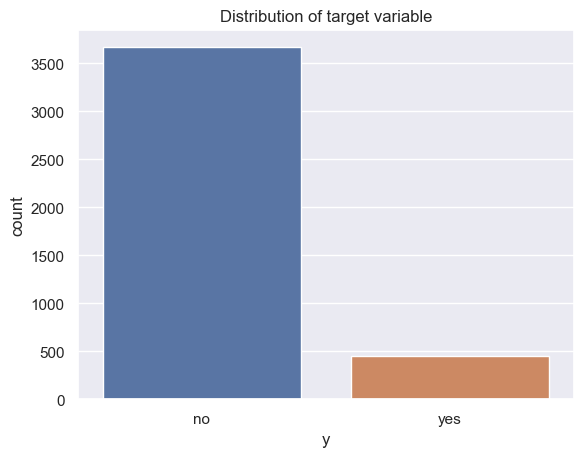

In [12]:
sns.set_theme()

sns.countplot(data=df_bank, x="y", hue="y")
plt.title("Distribution of target variable")
plt.show()

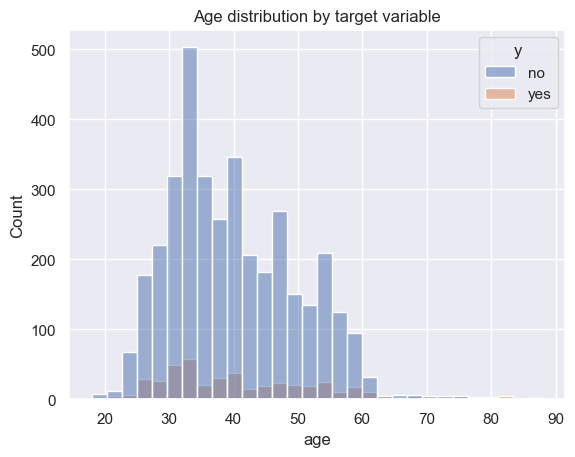

In [13]:
sns.histplot(data=df_bank, x="age", hue="y", bins=30)
plt.title("Age distribution by target variable")
plt.show()

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Removing default because many values are unknown
# I kept the other unknown values as their own dummy variables as they might be useful and were quite small in proportion
df_bank = df_bank.drop("default", axis=1, errors="ignore")

# Separating features and target
X = df_bank.drop("y", axis=1)
y = df_bank["y"]

# Converting target variable to numbers
y = y.map({"no": 0, "yes": 1})

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split into train + test first
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split training data again into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

# Scale data for models that need scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled_final = scaler.transform(X_test)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

This is a classification task because the target variable `y` is categorical.

I chose Random Forest because it was used in the course classification material and can model non-linear relationships. I chose KNN because it was covered in the course and classifies observations based on similar cases. I chose Logistic Regression as a simple baseline model for binary classification.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

results_validation = []

##### Random forest

In [16]:
for n_estimators in [50, 100, 200]:
    for max_depth in [3, 5, 10, None]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        results_validation.append({
            "model": "Random Forest",
            "parameters": f"n_estimators={n_estimators}, max_depth={max_depth}",
            "accuracy": accuracy_score(y_val, y_pred)
        })

#### KNN

In [17]:
for n_neighbors in [3, 5, 7, 9, 11, 15]:
    model = KNeighborsClassifier(n_neighbors=n_neighbors)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    results_validation.append({
        "model": "KNN",
        "parameters": f"n_neighbors={n_neighbors}",
        "accuracy": accuracy_score(y_val, y_pred)
    })

#### Logistic Regression

In [18]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    results_validation.append({
        "model": "Logistic Regression",
        "parameters": f"C={C}",
        "accuracy": accuracy_score(y_val, y_pred)
    })

df_results_validation = pd.DataFrame(results_validation)

display(df_results_validation.sort_values("accuracy", ascending=False))

,model,parameters,accuracy
22,Logistic Regression,C=100,0.916262
21,Logistic Regression,C=10,0.916262
20,Logistic Regression,C=1,0.916262
19,Logistic Regression,C=0.1,0.916262
7,Random Forest,"n_estimators=100, max_depth=None",0.906553
2,Random Forest,"n_estimators=50, max_depth=10",0.906553
18,Logistic Regression,C=0.01,0.905340
0,Random Forest,"n_estimators=50, max_depth=3",0.905340
6,Random Forest,"n_estimators=100, max_depth=10",0.905340
4,Random Forest,"n_estimators=100, max_depth=3",0.905340


d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

In [19]:
from sklearn.model_selection import cross_val_score

cv_results = []

#### Random Forest cross-validation

In [20]:
for n_estimators in [50, 100, 200]:
    for max_depth in [3, 5, 10, None]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        scores = cross_val_score(
            model,
            X_train_full,
            y_train_full,
            cv=5,
            scoring="accuracy"
        )

        cv_results.append({
            "model": "Random Forest",
            "parameters": f"n_estimators={n_estimators}, max_depth={max_depth}",
            "mean_accuracy": scores.mean(),
            "std_accuracy": scores.std()
        })

#### KNN cross-validation

In [21]:
for n_neighbors in [3, 5, 7, 9, 11, 15]:
    model = KNeighborsClassifier(n_neighbors=n_neighbors)

    scores = cross_val_score(
        model,
        X_train_full_scaled,
        y_train_full,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "model": "KNN",
        "parameters": f"n_neighbors={n_neighbors}",
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

#### Logistic Regression cross-validation

In [22]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)

    scores = cross_val_score(
        model,
        X_train_full_scaled,
        y_train_full,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "model": "Logistic Regression",
        "parameters": f"C={C}",
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

In [23]:
df_cv_results = pd.DataFrame(cv_results)

display(df_cv_results.sort_values("mean_accuracy", ascending=False))

,model,parameters,mean_accuracy,std_accuracy
7,Random Forest,"n_estimators=100, max_depth=None",0.911684,0.005292
18,Logistic Regression,C=0.01,0.911077,0.008233
19,Logistic Regression,C=0.1,0.910774,0.007642
6,Random Forest,"n_estimators=100, max_depth=10",0.910774,0.006024
3,Random Forest,"n_estimators=50, max_depth=None",0.910470,0.002539
20,Logistic Regression,C=1,0.910470,0.006145
22,Logistic Regression,C=100,0.910167,0.007459
21,Logistic Regression,C=10,0.910167,0.007459
11,Random Forest,"n_estimators=200, max_depth=None",0.909256,0.003513
2,Random Forest,"n_estimators=50, max_depth=10",0.909256,0.004335


In [24]:
print("Best validation split result:")
display(df_results_validation.sort_values("accuracy", ascending=False).head(1))

print("Best cross-validation result:")
display(df_cv_results.sort_values("mean_accuracy", ascending=False).head(1))

Best validation split result:


,model,parameters,accuracy
22,Logistic Regression,C=100,0.916262


Best cross-validation result:


,model,parameters,mean_accuracy,std_accuracy
7,Random Forest,"n_estimators=100, max_depth=None",0.911684,0.005292


The validation split evaluates each model using one fixed validation set, while cross-validation evaluates the model several times using different folds of the training data. In my results, the best validation accuracy was approximately 0.916, while the best cross-validation accuracy was approximately 0.912. Cross-validation is usually more reliable because the result depends less on one specific split of the data. Because of that, I use the cross-validation result when choosing the final model.

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_results = []

In [26]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train_full, y_train_full)
y_pred_rf = rf.predict(X_test)

test_results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1_score": f1_score(y_test, y_pred_rf)
})

In [27]:
# KNN
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_full_scaled, y_train_full)
y_pred_knn = knn.predict(X_test_scaled_final)

test_results.append({
    "model": "KNN",
    "accuracy": accuracy_score(y_test, y_pred_knn),
    "precision": precision_score(y_test, y_pred_knn),
    "recall": recall_score(y_test, y_pred_knn),
    "f1_score": f1_score(y_test, y_pred_knn)
})

In [28]:
# Logistic Regression
logreg = LogisticRegression(C=0.01, max_iter=1000, random_state=42)

logreg.fit(X_train_full_scaled, y_train_full)
y_pred_logreg = logreg.predict(X_test_scaled_final)

test_results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_logreg),
    "precision": precision_score(y_test, y_pred_logreg),
    "recall": recall_score(y_test, y_pred_logreg),
    "f1_score": f1_score(y_test, y_pred_logreg)
})

In [29]:
df_test_results = pd.DataFrame(test_results)

display(df_test_results.sort_values("f1_score", ascending=False))

,model,accuracy,precision,recall,f1_score
0,Random Forest,0.913835,0.731707,0.333333,0.458015
2,Logistic Regression,0.912621,0.764706,0.288889,0.419355
1,KNN,0.898058,0.615385,0.177778,0.275862


In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

final_model.fit(X_train_full, y_train_full)

y_pred_test = final_model.predict(X_test)

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95       734
           1       0.73      0.33      0.46        90

    accuracy                           0.91       824
   macro avg       0.83      0.66      0.71       824
weighted avg       0.90      0.91      0.90       824



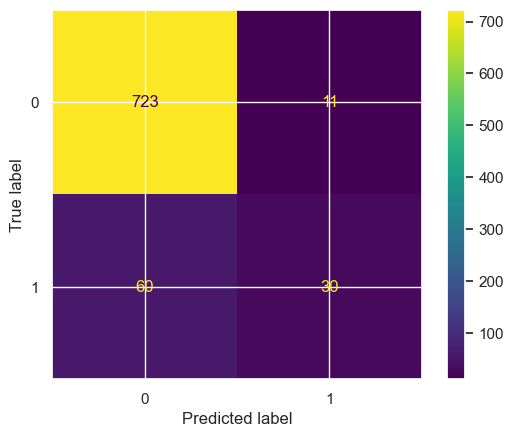

In [31]:
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Based on the test results, `Random Forest` is the best model for this task. It had the strongest overall performance and the best balance between accuracy, precision, recall and F1-score. Because the target variable is not balanced, I do not rely only on accuracy, but also consider F1-score and recall.